In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim import Optimizer
import torch.backends.cudnn as cudnn
import tqdm.notebook

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader, Subset
import torchvision.models as models
import torch.nn.functional as F

import os
import copy
import random
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv

random_seed = 0
np.random.seed(random_seed)
random.seed(random_seed)
torch.manual_seed(random_seed)

torch.cuda.set_device(0)
device = "cuda"

num_cpus = os.cpu_count()

In [3]:
## import models and util

# need to first download repository and add to path for Google Colab)
import sys

if not os.path.exists('/content/Narcissus'):
    !git clone https://github.com/reds-lab/Narcissus.git /content/Narcissus
sys.path.append('/content/Narcissus')

from models import *
from util import *

In [4]:
# download dataset
if not os.path.exists('/content/dataset/tiny-imagenet-200'):
    !mkdir -p /content/dataset/
    !wget -nc http://cs231n.stanford.edu/tiny-imagenet-200.zip -O /content/dataset/tiny-imagenet.zip
    !unzip -q /content/dataset/tiny-imagenet.zip -d /content/dataset/

In [5]:
# test run flag
# true makes the code run for feweer samples and epochs to make sure the code runs without errors
IS_TEST_RUN = True

In [6]:
"""
The path for target dataset and public out-of-distribution (POOD) dataset. The setting used
here is CIFAR-10 as the target dataset and Tiny-ImageNet as the POOD dataset. Their directory
structure is as follows:

dataset_path--cifar-10-batches-py
            |
            |-tiny-imagenet-200
"""

dataset_path = "/content/dataset/"
checkpoint_path = "/content/checkpoint/"
os.makedirs(dataset_path, exist_ok=True)
os.makedirs(checkpoint_path, exist_ok=True)

# The target class label
lab = 2

# Noise size, default is full image size
noise_size = 32

# Radius of the L-inf ball
l_inf_r = 16 / 255

# Model for generating surrogate model and trigger
surrogate_model = ResNet18_201().cuda()
generating_model = ResNet18_201().cuda()

# Surrogate model training epochs
surrogate_epochs = 200

# Learning rate for poison-warm-up
generating_lr_warmup = 0.1
warmup_round = 1  # changed from 5 to 1 for computational efficiency

# Learning rate for trigger generating
generating_lr_tri = 0.01
gen_round = 300  # changed from 1000 to 300 for computational efficiency

# Training batch size
train_batch_size = 350

# The model for adding the noise
patch_mode = "add"

In [7]:
if IS_TEST_RUN:
    surrogate_epochs = 100
    gen_round = 30
    train_batch_size = 64

# Prepare dataset


In [8]:
# The argumention use for surrogate model training stage
transform_surrogate_train = transforms.Compose(
    [
        transforms.Resize(32),
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

# The argumention use for all training set
transform_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

# The argumention use for all testing set
transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

In [9]:
ori_train = torchvision.datasets.CIFAR10(
    root=dataset_path, train=True, download=True, transform=transform_train
)
ori_test = torchvision.datasets.CIFAR10(
    root=dataset_path, train=False, download=True, transform=transform_test
)
outter_trainset = torchvision.datasets.ImageFolder(
    root=dataset_path + "tiny-imagenet-200/train/", transform=transform_surrogate_train
)

In [10]:
# Outter train dataset
train_label = [get_labels(ori_train)[x] for x in range(len(get_labels(ori_train)))]
test_label = [get_labels(ori_test)[x] for x in range(len(get_labels(ori_test)))]

In [11]:
# Inner train dataset
train_target_list = list(np.where(np.array(train_label) == lab)[0])
train_target = Subset(ori_train, train_target_list)

In [12]:
concoct_train_dataset = concoct_dataset(train_target, outter_trainset)

In [13]:
surrogate_loader = torch.utils.data.DataLoader(
    concoct_train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    num_workers=num_cpus,
)

poi_warm_up_loader = torch.utils.data.DataLoader(
    train_target, batch_size=train_batch_size, shuffle=True, num_workers=num_cpus
)

trigger_gen_loaders = torch.utils.data.DataLoader(
    train_target, batch_size=train_batch_size, shuffle=True, num_workers=num_cpus
)

In [14]:
if IS_TEST_RUN:
    # Only use the first 200 images for the smoke test
    smoke_test_indices = list(range(200))
    smoke_test_subset = Subset(concoct_train_dataset, smoke_test_indices)

    surrogate_loader = torch.utils.data.DataLoader(
        smoke_test_subset,  # Use the tiny subset
        batch_size=32,
        shuffle=True,
        num_workers=num_cpus,
    )

# Training surrogate modle


In [15]:
# Batch_grad
condition = True
noise = torch.zeros((1, 3, noise_size, noise_size), device=device)


surrogate_model = surrogate_model
criterion = torch.nn.CrossEntropyLoss()
# outer_opt = torch.optim.RAdam(params=base_model.parameters(), lr=generating_lr_outer)
surrogate_opt = torch.optim.SGD(
    params=surrogate_model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4
)
surrogate_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    surrogate_opt, T_max=surrogate_epochs
)

In [16]:
# Training the surrogate model
print("Training the surrogate model")
for epoch in range(0, surrogate_epochs):
    surrogate_model.train()
    loss_list = []
    for images, labels in surrogate_loader:
        images, labels = images.cuda(), labels.cuda()
        surrogate_opt.zero_grad()
        outputs = surrogate_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        loss_list.append(float(loss.data))
        surrogate_opt.step()
    surrogate_scheduler.step()
    ave_loss = np.average(np.array(loss_list))
    print("Epoch:%d, Loss: %.03f" % (epoch, ave_loss))
# Save the surrogate model
save_path = "./checkpoint/surrogate_pretrain_" + str(surrogate_epochs) + ".pth"
torch.save(surrogate_model.state_dict(), save_path)

Training the surrogate model
Epoch:0, Loss: 0.738
Epoch:1, Loss: 0.000
Epoch:2, Loss: 0.000
Epoch:3, Loss: 0.000
Epoch:4, Loss: 0.000
Epoch:5, Loss: 0.000
Epoch:6, Loss: 0.000
Epoch:7, Loss: 0.000
Epoch:8, Loss: 0.000
Epoch:9, Loss: 0.000
Epoch:10, Loss: 0.000
Epoch:11, Loss: 0.000
Epoch:12, Loss: 0.000
Epoch:13, Loss: 0.000
Epoch:14, Loss: 0.000
Epoch:15, Loss: 0.000
Epoch:16, Loss: 0.000
Epoch:17, Loss: 0.000
Epoch:18, Loss: 0.000
Epoch:19, Loss: 0.000
Epoch:20, Loss: 0.000
Epoch:21, Loss: 0.000
Epoch:22, Loss: 0.000
Epoch:23, Loss: 0.000
Epoch:24, Loss: 0.000
Epoch:25, Loss: 0.000
Epoch:26, Loss: 0.000
Epoch:27, Loss: 0.000
Epoch:28, Loss: 0.000
Epoch:29, Loss: 0.000
Epoch:30, Loss: 0.000
Epoch:31, Loss: 0.000
Epoch:32, Loss: 0.000
Epoch:33, Loss: 0.000
Epoch:34, Loss: 0.000
Epoch:35, Loss: 0.000
Epoch:36, Loss: 0.000
Epoch:37, Loss: 0.000
Epoch:38, Loss: 0.000
Epoch:39, Loss: 0.000
Epoch:40, Loss: 0.000
Epoch:41, Loss: 0.000
Epoch:42, Loss: 0.000
Epoch:43, Loss: 0.000
Epoch:44, Los

# Poison warm up


In [17]:
# Prepare models and optimizers for poi_warm_up training
poi_warm_up_model = generating_model
poi_warm_up_model.load_state_dict(surrogate_model.state_dict())

poi_warm_up_opt = torch.optim.RAdam(
    params=poi_warm_up_model.parameters(), lr=generating_lr_warmup
)

In [18]:
# Poi_warm_up stage
poi_warm_up_model.train()
for param in poi_warm_up_model.parameters():
    param.requires_grad = True

# Training the surrogate model
for epoch in range(0, warmup_round):
    poi_warm_up_model.train()
    loss_list = []
    for images, labels in poi_warm_up_loader:
        images, labels = images.cuda(), labels.cuda()
        poi_warm_up_model.zero_grad()
        poi_warm_up_opt.zero_grad()
        outputs = poi_warm_up_model(images)
        loss = criterion(outputs, labels)
        loss.backward(retain_graph=True)
        loss_list.append(float(loss.data))
        poi_warm_up_opt.step()
    ave_loss = np.average(np.array(loss_list))
    print("Epoch:%d, Loss: %e" % (epoch, ave_loss))

Epoch:0, Loss: 6.964141e+00


# Trigger generating


  0%|          | 0/30 [00:00<?, ?it/s]

Gradient: 0.00093830697 Loss: 0.0010421193969072007
Gradient: 0.2961305 Loss: 0.001050995984792568
Gradient: 0.0024540639 Loss: 0.0008522243380083856
Gradient: 0.000591038 Loss: 0.0008065849292103814
Gradient: 0.03958011 Loss: 0.0006927099260147897
Gradient: 0.00056448474 Loss: 0.0007064321413238333
Gradient: 0.0052301623 Loss: 0.0007043753863353565
Gradient: 0.0028720314 Loss: 0.0007075577999370857
Gradient: 0.0005355193 Loss: 0.0007237568663439088
Gradient: 0.004169164 Loss: 0.0007616629852777748
Gradient: 0.15571927 Loss: 0.000803472880750034
Gradient: 0.0010345718 Loss: 0.0007332768409123903
Gradient: 4.8016267e-05 Loss: 0.0007206906651661
Gradient: 3.0719734e-06 Loss: 0.0006136375296027606
Gradient: 0.00042756682 Loss: 0.0007227756080432807
Gradient: 0.009201057 Loss: 0.0007142193226403074
Gradient: 8.681144e-05 Loss: 0.0006095357243851404
Gradient: 2.6923404e-05 Loss: 0.0007099275158746227
Gradient: 0.00030457124 Loss: 0.0006431399024337754
Gradient: 9.688789e-05 Loss: 0.00068875

Gradient: 1.2922685e-05 Loss: 0.0006530490711985651


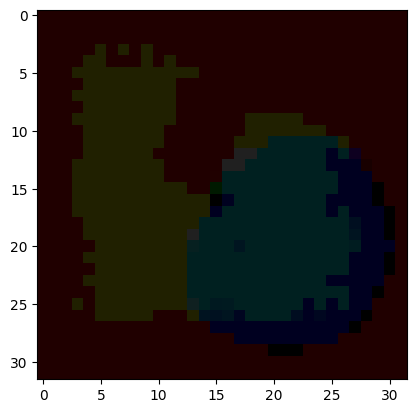

Noise max val: tensor(0.1255, device='cuda:0', grad_fn=<MaxBackward1>)


In [19]:
# Trigger generating stage
for param in poi_warm_up_model.parameters():
    param.requires_grad = False

batch_pert = torch.autograd.Variable(noise.cuda(), requires_grad=True)
batch_opt = torch.optim.RAdam(params=[batch_pert], lr=generating_lr_tri)
for minmin in tqdm.notebook.tqdm(range(gen_round)):
    loss_list = []
    for images, labels in trigger_gen_loaders:
        images, labels = images.cuda(), labels.cuda()
        new_images = torch.clone(images)
        clamp_batch_pert = torch.clamp(batch_pert, -l_inf_r * 2, l_inf_r * 2)
        new_images = torch.clamp(
            apply_noise_patch(clamp_batch_pert, new_images.clone(), mode=patch_mode),
            -1,
            1,
        )
        per_logits = poi_warm_up_model.forward(new_images)
        loss = criterion(per_logits, labels)
        loss_regu = torch.mean(loss)
        batch_opt.zero_grad()
        loss_list.append(float(loss_regu.data))
        loss_regu.backward(retain_graph=True)
        batch_opt.step()
    ave_loss = np.average(np.array(loss_list))
    ave_grad = np.sum(abs(batch_pert.grad).detach().cpu().numpy())
    print("Gradient:", ave_grad, "Loss:", ave_loss)
    if ave_grad == 0:
        break

noise = torch.clamp(batch_pert, -l_inf_r * 2, l_inf_r * 2)
best_noise = noise.clone().detach().cpu()
plt.imshow(np.transpose(noise[0].detach().cpu(), (1, 2, 0)))
plt.show()
print("Noise max val:", noise.max())

In [20]:
# Save the trigger
import time

save_name = (
    "./checkpoint/best_noise"
    + "_"
    + time.strftime("%m-%d-%H_%M_%S", time.localtime(time.time()))
)
np.save(save_name, best_noise)

# Testing attack effect


In [21]:
# Using this block if you only want to test the attack result.
# import imageio
# import cv2 as cv
# best_noise = torch.zeros((1, 3, noise_size, noise_size), device=device)
# noise_npy = np.load('./checkpoint/resnet18_trigger.npy')
# best_noise = torch.from_numpy(noise_npy).cuda()

In [22]:
# Poisoning amount use for the target class
poison_amount = 25

# Model uses for testing
noise_testing_model = ResNet18().cuda()

# Training parameters
training_epochs = 200
training_lr = 0.1
test_batch_size = 150

# The multiple of noise amplification during testing
multi_test = 3

# random seed for testing stage
random_seed = 65

In [23]:
if IS_TEST_RUN:
    training_epochs = 5  # Down from 100
    poison_amount = 10  # Ensure this is smaller than your subset

In [24]:
import torchvision.models as models

np.random.seed(random_seed)
random.seed(random_seed)
torch.manual_seed(random_seed)
model = noise_testing_model

optimizer = torch.optim.SGD(
    params=model.parameters(), lr=training_lr, momentum=0.9, weight_decay=5e-4
)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=training_epochs)

In [25]:
transform_tensor = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)
poi_ori_train = torchvision.datasets.CIFAR10(
    root=dataset_path, train=True, download=False, transform=transform_tensor
)
poi_ori_test = torchvision.datasets.CIFAR10(
    root=dataset_path, train=False, download=False, transform=transform_tensor
)
transform_after_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
    ]
)

In [26]:
# Poison traing
random_poison_idx = random.sample(train_target_list, poison_amount)
poison_train_target = poison_image(
    poi_ori_train, random_poison_idx, best_noise.cpu(), transform_after_train
)
print(
    "Traing dataset size is:",
    len(poison_train_target),
    " Poison numbers is:",
    len(random_poison_idx),
)
clean_train_loader = DataLoader(
    poison_train_target, batch_size=test_batch_size, shuffle=True, num_workers=2
)

Traing dataset size is: 50000  Poison numbers is: 10


In [27]:
# Attack success rate testing
test_non_target = list(np.where(np.array(test_label) != lab)[0])
test_non_target_change_image_label = poison_image_label(
    poi_ori_test, test_non_target, best_noise.cpu() * multi_test, lab, None
)
asr_loaders = torch.utils.data.DataLoader(
    test_non_target_change_image_label,
    batch_size=test_batch_size,
    shuffle=True,
    num_workers=2,
)
print("Poison test dataset size is:", len(test_non_target_change_image_label))

Poison test dataset size is: 9000


In [28]:
# Clean acc test dataset
clean_test_loader = torch.utils.data.DataLoader(
    ori_test, batch_size=test_batch_size, shuffle=False, num_workers=2
)

In [29]:
# Target clean test dataset
test_target = list(np.where(np.array(test_label) == lab)[0])
target_test_set = Subset(ori_test, test_target)
target_test_loader = torch.utils.data.DataLoader(
    target_test_set, batch_size=test_batch_size, shuffle=True, num_workers=2
)

In [30]:
from util import AverageMeter

train_ACC = []
test_ACC = []
clean_ACC = []
target_ACC = []

In [31]:
for epoch in tqdm.notebook.tqdm(range(training_epochs)):
    # Train
    model.train()
    acc_meter = AverageMeter()
    loss_meter = AverageMeter()
    pbar = tqdm.notebook.tqdm(clean_train_loader, total=len(clean_train_loader))
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        model.zero_grad()
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(logits.data, 1)
        acc = (predicted == labels).sum().item() / labels.size(0)
        acc_meter.update(acc)
        loss_meter.update(loss.item())
        pbar.set_description(
            "Acc %.2f Loss: %.2f" % (acc_meter.avg * 100, loss_meter.avg)
        )
    train_ACC.append(acc_meter.avg)
    print("Train_loss:", loss)
    scheduler.step()

    # Testing attack effect
    model.eval()
    correct, total = 0, 0
    for i, (images, labels) in enumerate(asr_loaders):
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            logits = model(images)
            out_loss = criterion(logits, labels)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = correct / total
    test_ACC.append(acc)
    print("\nAttack success rate %.2f" % (acc * 100))
    print("Test_loss:", out_loss)

    correct_clean, total_clean = 0, 0
    for i, (images, labels) in enumerate(clean_test_loader):
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            logits = model(images)
            out_loss = criterion(logits, labels)
            _, predicted = torch.max(logits.data, 1)
            total_clean += labels.size(0)
            correct_clean += (predicted == labels).sum().item()
    acc_clean = correct_clean / total_clean
    clean_ACC.append(acc_clean)
    print("\nTest clean Accuracy %.2f" % (acc_clean * 100))
    print("Test_loss:", out_loss)

    correct_tar, total_tar = 0, 0
    for i, (images, labels) in enumerate(target_test_loader):
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            logits = model(images)
            out_loss = criterion(logits, labels)
            _, predicted = torch.max(logits.data, 1)
            total_tar += labels.size(0)
            correct_tar += (predicted == labels).sum().item()
    acc_tar = correct_tar / total_tar
    target_ACC.append(acc_tar)
    print("\nTarget test clean Accuracy %.2f" % (acc_tar * 100))
    print("Test_loss:", out_loss)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/334 [00:00<?, ?it/s]

Train_loss: tensor(1.7404, device='cuda:0', grad_fn=<NllLossBackward0>)

Attack success rate 5.30
Test_loss: tensor(2.6159, device='cuda:0')

Test clean Accuracy 39.61
Test_loss: tensor(1.5447, device='cuda:0')

Target test clean Accuracy 1.60
Test_loss: tensor(2.1531, device='cuda:0')


  0%|          | 0/334 [00:00<?, ?it/s]

Train_loss: tensor(1.2333, device='cuda:0', grad_fn=<NllLossBackward0>)

Attack success rate 3.17
Test_loss: tensor(2.8517, device='cuda:0')

Test clean Accuracy 52.46
Test_loss: tensor(1.2501, device='cuda:0')

Target test clean Accuracy 29.80
Test_loss: tensor(1.9961, device='cuda:0')


...

Train_loss: tensor(1.2099, device='cuda:0', grad_fn=<NllLossBackward0>)

Attack success rate 5.18
Test_loss: tensor(2.5862, device='cuda:0')

Test clean Accuracy 60.18
Test_loss: tensor(1.1325, device='cuda:0')

Target test clean Accuracy 43.20
Test_loss: tensor(1.3427, device='cuda:0')


  0%|          | 0/334 [00:00<?, ?it/s]

Train_loss: tensor(0.9158, device='cuda:0', grad_fn=<NllLossBackward0>)

Attack success rate 9.74
Test_loss: tensor(3.0491, device='cuda:0')

Test clean Accuracy 68.58
Test_loss: tensor(0.9783, device='cuda:0')

Target test clean Accuracy 38.20
Test_loss: tensor(1.5890, device='cuda:0')


  0%|          | 0/334 [00:00<?, ?it/s]

Train_loss: tensor(0.7170, device='cuda:0', grad_fn=<NllLossBackward0>)

Attack success rate 30.37
Test_loss: tensor(2.0587, device='cuda:0')

Test clean Accuracy 74.49
Test_loss: tensor(0.7490, device='cuda:0')

Target test clean Accuracy 59.30
Test_loss: tensor(0.8770, device='cuda:0')


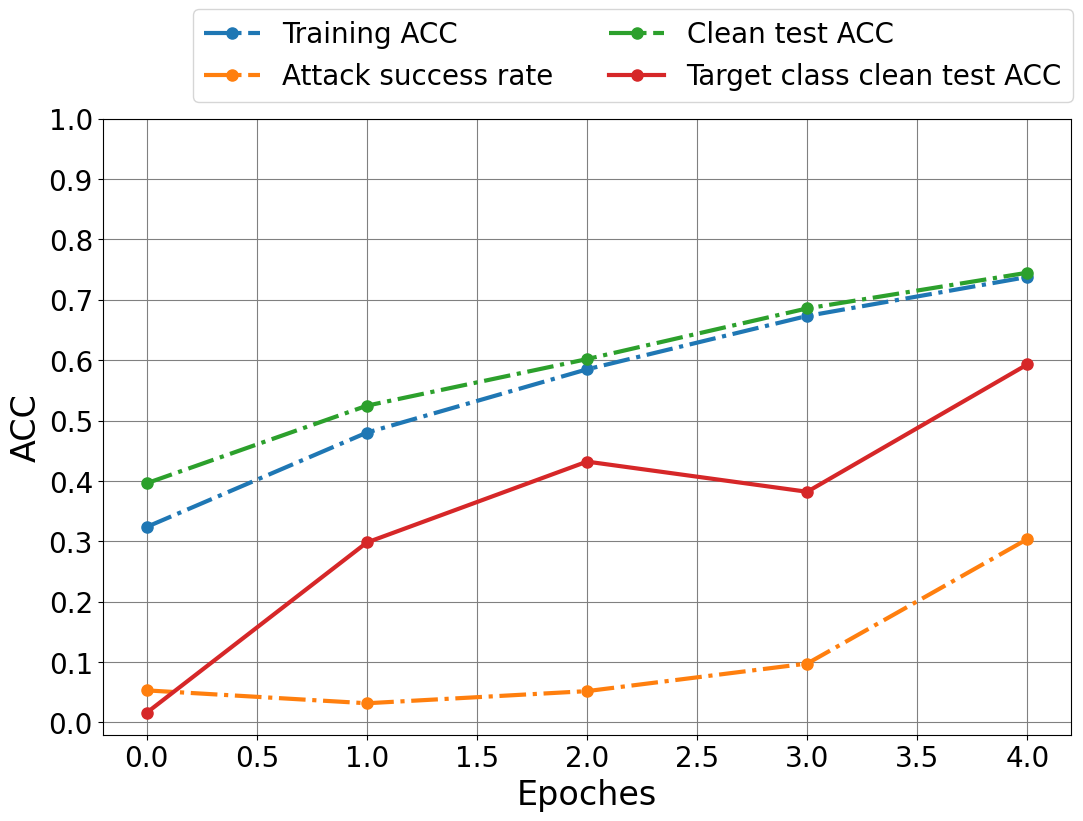

0.7378443113772454
attack 0.30366666666666664
4
all class clean 0.7449
target clean 0.593


In [32]:
# ours -- higher_configureations
from matplotlib import pyplot as plt

half = np.arange(0, training_epochs)
plt.figure(figsize=(12.5, 8))
plt.plot(
    half,
    np.asarray(train_ACC)[half],
    label="Training ACC",
    linestyle="-.",
    marker="o",
    linewidth=3.0,
    markersize=8,
)
plt.plot(
    half,
    np.asarray(test_ACC)[half],
    label="Attack success rate",
    linestyle="-.",
    marker="o",
    linewidth=3.0,
    markersize=8,
)
plt.plot(
    half,
    np.asarray(clean_ACC)[half],
    label="Clean test ACC",
    linestyle="-.",
    marker="o",
    linewidth=3.0,
    markersize=8,
)
plt.plot(
    half,
    np.asarray(target_ACC)[half],
    label="Target class clean test ACC",
    linestyle="-",
    marker="o",
    linewidth=3.0,
    markersize=8,
)
# plt.plot(half, np.asarray(test_unl_ACC)[half], label='protected test ACC', linestyle="-.", marker="o", linewidth=3.0, markersize = 8)
plt.ylabel("ACC", fontsize=24)
plt.xticks(fontsize=20)
plt.xlabel("Epoches", fontsize=24)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=20)
plt.legend(fontsize=20, bbox_to_anchor=(1.016, 1.2), ncol=2)
plt.grid(color="gray", linestyle="-")
plt.show()

dis_idx = clean_ACC.index(max(clean_ACC))
print(train_ACC[dis_idx])
print("attack", test_ACC[dis_idx])
print(clean_ACC.index(max(clean_ACC)))
print("all class clean", clean_ACC[dis_idx])
print("target clean", target_ACC[dis_idx])